# Part 1

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv("spambase/spambase.data", header=None)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
trees = [10, 50, 100, 500]

results = []

for T in trees:
    rf = RandomForestClassifier(
        n_estimators=T,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    # Probabilities
    y_train_prob = rf.predict_proba(X_train)[:, 1]
    y_test_prob = rf.predict_proba(X_test)[:, 1]
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    results.append([T, train_acc, test_acc, train_f1, test_f1, train_auc, test_auc])

In [4]:
for r in results:
    print(f"T={r[0]} | Train Acc={r[1]:.4f}, Test Acc={r[2]:.4f}, "
          f"Train F1={r[3]:.4f}, Test F1={r[4]:.4f}, "
          f"Train AUC={r[5]:.4f}, Test AUC={r[6]:.4f}")

T=10 | Train Acc=0.9946, Test Acc=0.9403, Train F1=0.9929, Test F1=0.9262, Train AUC=0.9999, Test AUC=0.9745
T=50 | Train Acc=0.9995, Test Acc=0.9501, Train F1=0.9993, Test F1=0.9390, Train AUC=1.0000, Test AUC=0.9834
T=100 | Train Acc=0.9995, Test Acc=0.9555, Train F1=0.9993, Test F1=0.9458, Train AUC=1.0000, Test AUC=0.9852
T=500 | Train Acc=0.9995, Test Acc=0.9577, Train F1=0.9993, Test F1=0.9485, Train AUC=1.0000, Test AUC=0.9858


# Part 3

In [5]:
import matplotlib.pyplot as plt

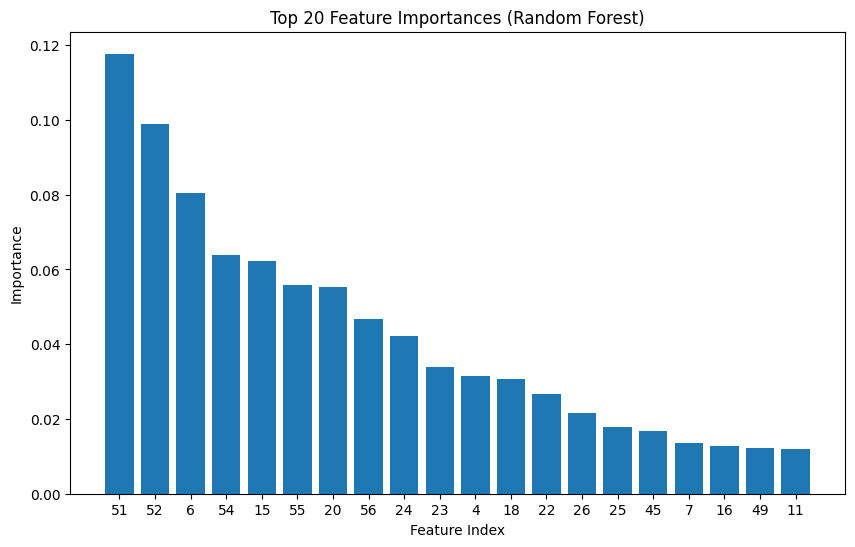

In [6]:
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), indices[:20])
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()